In [ ]:
pip install pandas

In [ ]:
import pandas as pd

In [ ]:
url='https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

In [ ]:
titanic=pd.read_csv(url)

In [ ]:
titanic.head()# lists the top 5 rows of the dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic.isna().sum() #identify the no.of missing values

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
titanic = titanic.drop(['Cabin','Ticket'],axis=1) #removing unwanted columns from the dataset using isna()

In [ ]:
titanic['Age'].median()

28.0

In [ ]:
titanic['Age'].fillna(titanic['Age'].median(),inplace=True) #filling the values using the function 'fillna()'

/tmp/ipython-input-4247855172.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(),inplace=True)


In [ ]:
titanic.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2


In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [ ]:
titanic['Embarked'].fillna('S',inplace=True)

/tmp/ipython-input-3979945394.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Embarked'].fillna('S',inplace=True)


In [ ]:
titanic.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
titanic.dtypes #list the datatypes of the dataset

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,object


***Analyzing survival rates by passenger class***

In [ ]:
survival_by_class = titanic.groupby('Pclass')['Survived'].mean()

Visualizing the dataset using **Matplotlib**

In [ ]:
import matplotlib.pyplot as plt


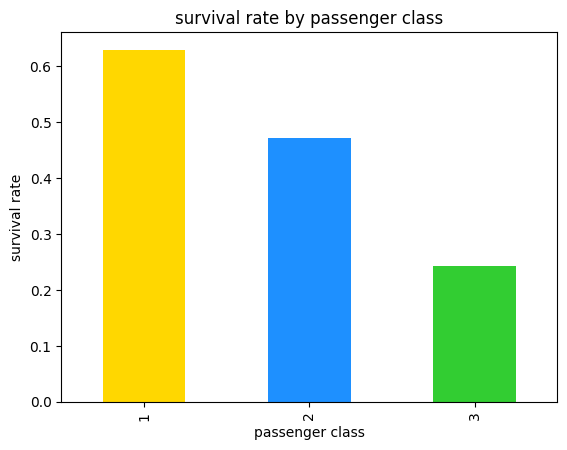

In [ ]:
survival_by_class.plot(kind='bar',color=['#FFD700','#1E90FF','#32CD32'])
plt.title('survival rate by passenger class')
plt.xlabel('passenger class')
plt.ylabel('survival rate')
plt.show()

🔹 Passenger Class Insight:
Survival rates were highest among first-class passengers, followed by second-class, and lowest among third-class passengers. This suggests that socio-economic status and proximity to lifeboats played a significant role in survival

Survivors rate by **AGE**

In [ ]:
titanic['Age'].describe()

,Age
count,891.000000
mean,29.361582
std,13.019697
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


In [ ]:
titanic['AgeGroup']=pd.cut(
    titanic['Age'],
    bins=[0,12,18,50,100],
    labels=['Child','Teen','Adult','senior']
)

In [ ]:
titanic.groupby('AgeGroup')['Survived'].mean()

/tmp/ipython-input-1582545677.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby('AgeGroup')['Survived'].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.428571
Adult,0.363372
senior,0.343750


In [ ]:
survived_by_age=titanic.groupby('AgeGroup')['Survived'].mean()

/tmp/ipython-input-4254231824.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_by_age=titanic.groupby('AgeGroup')['Survived'].mean()


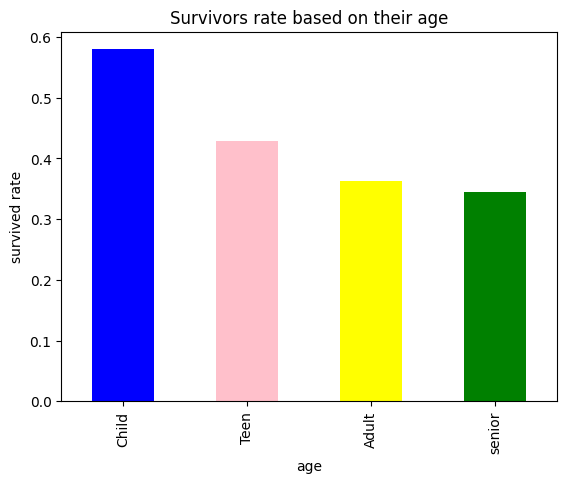

In [ ]:
survived_by_age.plot(
    kind='bar',
    color=['blue','pink','yellow','green']
)
plt.title('Survivors rate based on their age')
plt.xlabel('age')
plt.ylabel('survived rate')
plt.show()

🔹 Age Insight:
Children and teenagers showed higher survival rates, likely due to evacuation priority, while senior passengers had lower survival rates, possibly due to mobility limitations

SURVIVORS RATE BY **GENDER**

In [ ]:
survivors_by_gender=titanic.groupby('Sex')['Survived'].mean()

In [ ]:
titanic.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


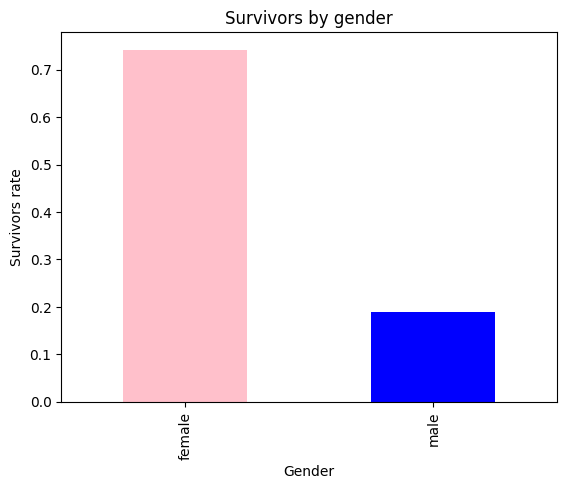

In [ ]:
survivors_by_gender.plot(
    kind='bar',
    color=['pink','blue']
)
plt.title("Survivors by gender")
plt.xlabel("Gender")
plt.ylabel('Survivors rate')
plt.show()

🔹 Gender Insight:
Women had a significantly higher survival rate than men, reflecting the historical evacuation practice of “women and children first.”